In [ ]:
# Copyright 2025 Google LLC

# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at

#     https://www.apache.org/licenses/LICENSE-2.0

# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Building Knowledge Graphs with Gemini

> ![Lab Preview](https://github.com/PicardParis/cherry-on-py-pics/raw/main/misc/Building-Knowledge-Graphs-with-Gemini.png)


| Author                                           |
| ------------------------------------------------ |
| [Laurent Picard](https://github.com/PicardParis) |


---

## 🔥 Challenge


Can we extract knowledge from documents with just the following?

- 1 document
- 1 prompt
- 1 request

Let's try with Gemini…


---

## 🏁 Setup


### 🐍 Python packages


We'll use the following packages:

- `google-genai`: The [Google Gen AI Python SDK](https://pypi.org/project/google-genai) lets us call Gemini with a few lines of code
- `networkx` for graph management

We'll also use the following dependencies:

- `networkx` and `pillow` for data visualization
- `tenacity` for request management


In [1]:
%pip install --quiet "google-genai>=1.53.0" "networkx[default]"

---

### 🔗 Gemini API


To use the Gemini API, we have two main options:

1. Via **Vertex AI** with a Google Cloud project
2. Via **Google AI Studio** with a Gemini API key

The Google Gen AI SDK provides a unified interface to these APIs and we can use environment variables for the configuration.

**🛠️ Option 1 - Gemini API via Vertex AI**

Requirements:

- A Google Cloud project
- The Vertex AI API must be enabled for this project: ▶️ [Enable the Vertex AI API](https://console.cloud.google.com/flows/enableapi?apiid=aiplatform.googleapis.com,storage-component.googleapis.com)

Gen AI SDK environment variables:

- `GOOGLE_GENAI_USE_VERTEXAI="True"`
- `GOOGLE_CLOUD_PROJECT="<PROJECT_ID>"`
- `GOOGLE_CLOUD_LOCATION="<LOCATION>"`

> 💡 For preview models, the location must be set to `global`. For generally available models, we can choose the closest location among the [Google model endpoint locations](https://cloud.google.com/vertex-ai/generative-ai/docs/learn/locations#google_model_endpoint_locations).

> ℹ️ Learn more about [setting up a project and a development environment](https://cloud.google.com/vertex-ai/docs/start/cloud-environment).

**🛠️ Option 2 - Gemini API via Google AI Studio**

Requirement:

- A Gemini API key

Gen AI SDK environment variables:

- `GOOGLE_GENAI_USE_VERTEXAI="False"`
- `GOOGLE_API_KEY="<API_KEY>"`

> ℹ️ Learn more about [getting a Gemini API key from Google AI Studio](https://aistudio.google.com/app/apikey).


💡 You can store your environment configuration outside of the source code:

| Environment         | Method                                                      |
| ------------------- | ----------------------------------------------------------- |
| IDE                 | `.env` file (or equivalent)                                 |
| Colab               | Colab Secrets (🗝️ icon in left panel, see code below)       |
| Colab Enterprise    | Google Cloud project and location are automatically defined |
| Vertex AI Workbench | Google Cloud project and location are automatically defined |


Define the following environment detection functions. You can also define your configuration manually if needed.


In [2]:
# @title {display-mode: "form"}

import os
import sys
from collections.abc import Callable

from google import genai

# Manual setup (leave unchanged if setup is environment-defined)

# @markdown **Which API: Vertex AI or Google AI Studio?**
GOOGLE_GENAI_USE_VERTEXAI = True  # @param {type: "boolean"}

# @markdown **Option A - Google Cloud project [+location]**
GOOGLE_CLOUD_PROJECT = "analog-oven-480713-v4"  # @param {type: "string"}
GOOGLE_CLOUD_LOCATION = "europe-west1"  # @param {type: "string"}

# @markdown **Option B - Google AI Studio API key**
GOOGLE_API_KEY = ""  # @param {type: "string"}


def check_environment() -> bool:
    check_colab_user_authentication()
    return check_manual_setup() or check_vertex_ai() or check_colab() or check_local()


def check_manual_setup() -> bool:
    return check_define_env_vars(
        GOOGLE_GENAI_USE_VERTEXAI,
        GOOGLE_CLOUD_PROJECT.strip(),  # Might have been pasted with line return
        GOOGLE_CLOUD_LOCATION,
        GOOGLE_API_KEY,
    )


def check_vertex_ai() -> bool:
    # Workbench and Colab Enterprise
    match os.getenv("VERTEX_PRODUCT", ""):
        case "WORKBENCH_INSTANCE":
            pass
        case "COLAB_ENTERPRISE":
            if not running_in_colab_env():
                return False
        case _:
            return False

    return check_define_env_vars(
        True,
        os.getenv("GOOGLE_CLOUD_PROJECT", ""),
        os.getenv("GOOGLE_CLOUD_REGION", ""),
        "",
    )


def check_colab() -> bool:
    if not running_in_colab_env():
        return False

    # Colab Enterprise was checked before, so this is Colab only
    from google.colab import auth as colab_auth  # type: ignore

    colab_auth.authenticate_user()

    # Use Colab Secrets (🗝️ icon in left panel) to store the environment variables
    # Secrets are private, visible only to you and the notebooks that you select
    # - Vertex AI: Store your settings as secrets
    # - Google AI: Directly import your Gemini API key from the UI
    vertexai, project, location, api_key = get_vars(get_colab_secret)

    return check_define_env_vars(vertexai, project, location, api_key)


def check_local() -> bool:
    vertexai, project, location, api_key = get_vars(os.getenv)

    return check_define_env_vars(vertexai, project, location, api_key)


def running_in_colab_env() -> bool:
    # Colab or Colab Enterprise
    return "google.colab" in sys.modules


def check_colab_user_authentication() -> None:
    if running_in_colab_env():
        from google.colab import auth as colab_auth  # type: ignore

        colab_auth.authenticate_user()


def get_colab_secret(secret_name: str, default: str) -> str:
    from google.colab import errors, userdata  # type: ignore

    try:
        return userdata.get(secret_name)
    except errors.SecretNotFoundError:
        return default


def get_vars(getenv: Callable[[str, str], str]) -> tuple[bool, str, str, str]:
    # Limit getenv calls to the minimum (may trigger UI confirmation for secret access)
    vertexai_str = getenv("GOOGLE_GENAI_USE_VERTEXAI", "")
    if vertexai_str:
        vertexai = vertexai_str.lower() in ["true", "1"]
    else:
        vertexai = bool(getenv("GOOGLE_CLOUD_PROJECT", ""))

    project = getenv("GOOGLE_CLOUD_PROJECT", "") if vertexai else ""
    location = getenv("GOOGLE_CLOUD_LOCATION", "") if project else ""
    api_key = getenv("GOOGLE_API_KEY", "") if not project else ""

    return vertexai, project, location, api_key


def check_define_env_vars(
    vertexai: bool,
    project: str,
    location: str,
    api_key: str,
) -> bool:
    match (vertexai, bool(project), bool(location), bool(api_key)):
        case (True, True, _, _):
            # Vertex AI - Google Cloud project [+location]
            location = location or "global"
            define_env_vars(vertexai, project, location, "")
        case (True, False, _, True):
            # Vertex AI - API key
            define_env_vars(vertexai, "", "", api_key)
        case (False, _, _, True):
            # Google AI Studio - API key
            define_env_vars(vertexai, "", "", api_key)
        case _:
            return False

    return True


def define_env_vars(vertexai: bool, project: str, location: str, api_key: str) -> None:
    os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = str(vertexai)
    os.environ["GOOGLE_CLOUD_PROJECT"] = project
    os.environ["GOOGLE_CLOUD_LOCATION"] = location
    os.environ["GOOGLE_API_KEY"] = api_key


def check_configuration(client: genai.Client) -> None:
    service = "Vertex AI" if client.vertexai else "Google AI Studio"
    print(f"Using the {service} API", end="")

    if client._api_client.project:
        print(f' with project "{client._api_client.project[:7]}…"', end="")
        print(f' in location "{client._api_client.location}"')
    elif client._api_client.api_key:
        api_key = client._api_client.api_key
        print(f' with API key "{api_key[:5]}…{api_key[-5:]}"', end="")
        print(f" (in case of error, make sure it was created for {service})")

---

### 🤖 Gen AI SDK


Create a `google.genai` client:


In [3]:
from google import genai

check_environment()

client = genai.Client()

Check your configuration:


In [4]:
check_configuration(client)

Using the Vertex AI API with project "analog-…" in location "europe-west1"


---

### 🔣 Data


In [6]:
# @title {display-mode: "form"}

import enum
from collections.abc import Iterator

from google.genai.types import Part


# Abstract class for data sources
class Source(enum.Enum):
    def yield_contents(self) -> Iterator[Part]: ...


# Public domain
class Text(Source):
    en_les_misérables = "en-GTB-135_Les Misérables-TOK-000_742_728-CHR-002_644_606.txt"
    en_war_and_peace = "en-GTB-2600_War and Peace-TOK-000_722_904-CHR-002_628_447.txt"
    en_count_of_monte_cristo = (
        "en-GTB-1184_The Count of Monte Cristo-TOK-000_613_748-CHR-002_147_939.txt"
    )
    en_don_quixote = "en-GTB-996_Don Quixote-TOK-000_524_770-CHR-001_863_098.txt"
    en_anna_karenina = "en-GTB-1399_Anna Karenina-TOK-000_457_784-CHR-001_607_002.txt"
    en_brothers_karamazov = (
        "en-GTB-28054_The Brothers Karamazov-TOK-000_462_509-CHR-001_577_879.txt"
    )
    en_three_musketeers = (
        "en-GTB-1257_The three musketeers-TOK-000_311_370-CHR-001_059_772.txt"
    )
    en_twenty_years_after = (
        "en-GTB-1259_Twenty years after-TOK-000_333_519-CHR-001_114_571.txt"
    )
    en_man_in_iron_mask = (
        "en-GTB-2759_The Man in the Iron Mask-TOK-000_233_321-CHR-000_800_099.txt"
    )
    en_hunchback_notre_dame = (
        "en-GTB-2610_Notre-Dame de Paris-TOK-000_279_447-CHR-000_869_698.txt"
    )
    fr_trois_mousquetaires = (
        "fr-GTB-13951_Les trois mousquetaires-TOK-000_361_745-CHR-001_088_781.txt"
    )
    fr_vingt_ans_après = (
        "fr-GTB-13952_Vingt ans après-TOK-000_455_680-CHR-001_363_211.txt"
    )
    fr_comte_de_monte_cristo_1 = "fr-GTB-17989_Le comte de Monte-Cristo, Tome I-TOK-000_195_133-CHR-000_601_261.txt"
    fr_comte_de_monte_cristo_2 = "fr-GTB-17990_Le comte de Monte-Cristo, Tome II-TOK-000_187_002-CHR-000_584_325.txt"
    fr_comte_de_monte_cristo_3 = "fr-GTB-17991_Le comte de Monte-Cristo, Tome III-TOK-000_181_953-CHR-000_555_911.txt"
    fr_comte_de_monte_cristo_4 = "fr-GTB-17992_Le comte de Monte-Cristo, Tome IV-TOK-000_195_876-CHR-000_591_785.txt"
    fr_therese_raquin = "fr-GTB-7461_Thérèse Raquin-TOK-000_104_251-CHR-000_335_375.txt"
    es_don_quijote = "es-GTB-2000_Don Quijote-TOK-000_538_601-CHR-001_718_350.txt"
    de_wilhelm_meisters_lehrjahre_1 = "de-GTB-2342_Wilhelm Meisters Lehrjahre — Band 8-TOK-000_055_121-CHR-000_197_017.txt"
    de_wilhelm_meisters_lehrjahre_2 = "de-GTB-2335_Wilhelm Meisters Lehrjahre — Band 1-TOK-000_032_070-CHR-000_115_172.txt"
    de_wilhelm_meisters_lehrjahre_3 = "de-GTB-2336_Wilhelm Meisters Lehrjahre — Band 2-TOK-000_032_982-CHR-000_117_361.txt"
    de_wilhelm_meisters_lehrjahre_4 = "de-GTB-2337_Wilhelm Meisters Lehrjahre — Band 3-TOK-000_027_314-CHR-000_099_302.txt"
    de_wilhelm_meisters_lehrjahre_5 = "de-GTB-2338_Wilhelm Meisters Lehrjahre — Band 4-TOK-000_038_625-CHR-000_137_824.txt"
    de_wilhelm_meisters_lehrjahre_6 = "de-GTB-2339_Wilhelm Meisters Lehrjahre — Band 5-TOK-000_035_710-CHR-000_129_506.txt"
    de_wilhelm_meisters_lehrjahre_7 = "de-GTB-2340_Wilhelm Meisters Lehrjahre — Band 6-TOK-000_030_637-CHR-000_112_102.txt"
    de_wilhelm_meisters_lehrjahre_8 = "de-GTB-2341_Wilhelm Meisters Lehrjahre — Band 7-TOK-000_038_259-CHR-000_134_352.txt"
    el_Πολιτεία_1 = "el-GTB-39530_Πολιτεία, Τόμος 4-TOK-000_081_099-CHR-000_169_034.txt"
    el_Πολιτεία_2 = "el-GTB-39476_Πολιτεία, Τόμος 1-TOK-000_067_432-CHR-000_139_207.txt"
    el_Πολιτεία_3 = "el-GTB-39493_Πολιτεία, Τόμος 2-TOK-000_093_427-CHR-000_194_389.txt"
    el_Πολιτεία_4 = "el-GTB-39524_Πολιτεία, Τόμος 3-TOK-000_059_333-CHR-000_124_483.txt"
    el_36284_Νόμοι_και_Επινομίς_1 = (
        "el-GTB-36284_Νόμοι και Επινομίς, Τόμος Δ-TOK-000_075_761-CHR-000_143_443.txt"
    )
    el_36088_Νόμοι_και_Επινομίς_2 = (
        "el-GTB-36088_Νόμοι και Επινομίς, Τόμος Α-TOK-000_073_683-CHR-000_135_496.txt"
    )
    el_36116_Νόμοι_και_Επινομίς_3 = (
        "el-GTB-36116_Νόμοι και Επινομίς, Τόμος B-TOK-000_089_012-CHR-000_169_713.txt"
    )
    el_36191_Νόμοι_και_Επινομίς_4 = (
        "el-GTB-36191_Νόμοι και Επινομίς, Τόμος Γ-TOK-000_085_470-CHR-000_161_247.txt"
    )
    el_36262_Νόμοι_και_Επινομίς_5 = (
        "el-GTB-36262_Νόμοι και Επινομίς, Τόμος Ε-TOK-000_060_263-CHR-000_115_401.txt"
    )
    it_divina_commedia = (
        "it-GTB-1012_La Divina Commedia di Dante-TOK-000_185_435-CHR-000_429_874.txt"
    )
    nl_joost_van_vondel = "nl-GTB-55929_De complete werken van Joost van Vondel. Hymnus of Lofzang van de Kristelijke Ridder, [etc.]-TOK-000_063_810-CHR-000_150_772.txt"
    ru_14741_Духовные = "ru-GTB-14741_Духовные оды-TOK-000_039_134-CHR-000_090_466.txt"
    ru_30774_Московия = "ru-GTB-30774_Московия в представлении иностранцев XVI-XVII в-TOK-000_015_748-CHR-000_039_033.txt"
    he_4778_sipurim = (
        "he-GTB-4778_Sipurim (Stories)-TOK-000_136_722-CHR-000_255_263.txt"
    )
    zh_24042_徬徨 = "zh-GTB-24042_徬徨-TOK-000_050_482-CHR-000_059_713.txt"
    zh_25559_中國小說史略 = (
        "zh-GTB-25559_中國小說史略-TOK-000_200_731-CHR-000_216_157.txt"
    )
    zh_27166_吶喊 = "zh-GTB-27166_吶喊-TOK-000_070_674-CHR-000_079_779.txt"
    ja_1982_羅生門 = "ja-GTB-1982_羅生門-TOK-000_004_070-CHR-000_006_288.txt"
    ja_32941_何處へ = "ja-GTB-32941_何處へ-TOK-000_240_833-CHR-000_292_027.txt"
    ja_31757_お目出たき人 = (
        "ja-GTB-31757_お目出たき人-TOK-000_035_512-CHR-000_052_569.txt"
    )
    te_39004_శుభలేఖ = "te-GTB-39004_శుభలేఖ-TOK-000_090_286-CHR-000_129_774.txt"

    def yield_contents(self) -> Iterator[Part]:
        uri = f"gs://lpdemo-misc/gtb/{self.value}"
        yield Part.from_uri(file_uri=uri, mime_type="text/plain")


# Collections of public domain sources
class Collection(Source):
    en_three_musketeers_twenty_years_after = [
        Text.en_three_musketeers,
        Text.en_twenty_years_after,
    ]
    fr_trois_mousquetaires_vingt_ans_après = [
        Text.fr_trois_mousquetaires,
        Text.fr_vingt_ans_après,
    ]
    fr_comte_de_monte_cristo = [
        Text.fr_comte_de_monte_cristo_1,
        Text.fr_comte_de_monte_cristo_2,
        Text.fr_comte_de_monte_cristo_3,
        Text.fr_comte_de_monte_cristo_4,
    ]
    de_wilhelm_meisters_lehrjahre = [
        Text.de_wilhelm_meisters_lehrjahre_1,
        Text.de_wilhelm_meisters_lehrjahre_2,
        Text.de_wilhelm_meisters_lehrjahre_3,
        Text.de_wilhelm_meisters_lehrjahre_4,
        Text.de_wilhelm_meisters_lehrjahre_5,
        Text.de_wilhelm_meisters_lehrjahre_6,
        Text.de_wilhelm_meisters_lehrjahre_7,
        Text.de_wilhelm_meisters_lehrjahre_8,
    ]
    el_Πολιτεία = [
        Text.el_Πολιτεία_1,
        Text.el_Πολιτεία_2,
        Text.el_Πολιτεία_3,
        Text.el_Πολιτεία_4,
    ]
    el_Νόμοι_Επινομίς = [
        Text.el_36284_Νόμοι_και_Επινομίς_1,
        Text.el_36088_Νόμοι_και_Επινομίς_2,
        Text.el_36116_Νόμοι_και_Επινομίς_3,
        Text.el_36191_Νόμοι_και_Επινομίς_4,
        Text.el_36262_Νόμοι_και_Επινομίς_5,
    ]

    def yield_contents(self) -> Iterator[Part]:
        for text in self.value:
            yield from text.yield_contents()

---

## 🧠 Gemini model


Gemini comes in different [versions](https://cloud.google.com/vertex-ai/generative-ai/docs/learn/models#gemini-models).

Let's pick Gemini 2.5 Flash, as it offers high performance, low latency, and a long 65,536 token output limit:

```python
GEMINI_2_5_FLASH = "gemini-2.5-flash"
```


---

## ⚙️ Gemini configuration


Gemini can be used in different ways, ranging from factual to creative mode. The problem we're trying to solve is a **data extraction** use case. We want results as factual and deterministic as possible. For this, we can change the [content generation parameters](https://cloud.google.com/vertex-ai/generative-ai/docs/multimodal/content-generation-parameters).

We'll set the `temperature`, `top_p`, and `seed` parameters to minimize randomness:

- `temperature=0.0`
- `top_p=0.0`
- `seed=42` (arbitrary fixed value)


---

## 🛠️ Helpers


In [7]:
# @title {display-mode: "form"}

import IPython.display
import tenacity
from google.genai.errors import ClientError
from google.genai.types import (
    FinishReason,
    GenerateContentConfig,
    GenerateContentResponse,
    ThinkingConfig,
)


class Model(enum.Enum):
    # Generally Available (GA)
    GEMINI_2_5_FLASH = "gemini-2.5-flash"
    GEMINI_2_5_PRO = "gemini-2.5-pro"
    # Default model
    DEFAULT = GEMINI_2_5_FLASH


# Default configuration for more deterministic outputs
DEFAULT_CONFIG = GenerateContentConfig(
    temperature=0.0,
    top_p=0.0,
    seed=42,
)


class ShowResponseAs(enum.Enum):
    DONT_SHOW = enum.auto()
    TEXT = enum.auto()
    MARDKDOWN = enum.auto()


def generate_content(
    prompt: str,
    source: Source | None = None,
    model: Model | None = None,
    config: GenerateContentConfig | None = None,
    show_as: ShowResponseAs = ShowResponseAs.MARDKDOWN,
) -> None:
    def yield_contents() -> Iterator[str | Part]:
        if source:
            yield "<TEXT>\n"
            yield from source.yield_contents()
            yield "\n</TEXT>\n"
        yield "<INSTRUCTIONS>\n"
        yield prompt.strip()
        yield "\n</INSTRUCTIONS>\n"

    model = model or Model.DEFAULT
    model_id = model.value
    contents = list(yield_contents())
    config = config or get_generate_content_config_for_tests(model)

    caption = f"{source.name} / {model_id}" if source else model_id
    print(f" {caption} ".center(80, "-"))
    for attempt in get_retrier():
        with attempt:
            response = client.models.generate_content(
                model=model_id,
                contents=contents,  # type: ignore
                config=config,
            )
            display_response_info(response)
            display_response(response, show_as)


def get_generate_content_config_for_tests(model: Model) -> GenerateContentConfig:
    thinking_config = get_thinking_config(model)

    return GenerateContentConfig(
        temperature=DEFAULT_CONFIG.temperature,
        top_p=DEFAULT_CONFIG.top_p,
        seed=DEFAULT_CONFIG.seed,
        max_output_tokens=4000,  # Limit output for tests (to fail fast)
        thinking_config=thinking_config,
    )


def get_thinking_config(model: Model) -> ThinkingConfig | None:
    # Examples of thinking configurations (Gemini 2.5 models)
    match model:
        case Model.GEMINI_2_5_FLASH:  # Disable thinking
            return ThinkingConfig(thinking_budget=0, include_thoughts=False)
        case Model.GEMINI_2_5_PRO:  # Minimum thinking budget and no thought summary
            return ThinkingConfig(thinking_budget=128, include_thoughts=False)
        case _:
            return None  # Default


def get_retrier() -> tenacity.Retrying:
    return tenacity.Retrying(
        stop=tenacity.stop_after_attempt(7),
        wait=tenacity.wait_incrementing(start=10, increment=1),
        retry=should_retry_request,
        reraise=True,
    )


def should_retry_request(retry_state: tenacity.RetryCallState) -> bool:
    if not retry_state.outcome:
        return False
    err = retry_state.outcome.exception()
    if not isinstance(err, ClientError):
        return False
    print(f"❌ ClientError {err.code}: {err.message}")

    retry = False
    match err.code:
        case 400 if err.message is not None and " try again " in err.message:
            # Workshop: project accessing Cloud Storage for the first time (service agent provisioning)
            retry = True
        case 429:
            # Workshop: temporary project with 1 QPM quota
            retry = True
    print(f"🔄 Retry: {retry}")

    return retry


def display_response_info(response: GenerateContentResponse) -> None:
    if usage_metadata := response.usage_metadata:
        if usage_metadata.prompt_token_count:
            print(f"Input tokens   : {usage_metadata.prompt_token_count:9,d}")
        if usage_metadata.candidates_token_count:
            print(f"Output tokens  : {usage_metadata.candidates_token_count:9,d}")
        if usage_metadata.thoughts_token_count:
            print(f"Thoughts tokens: {usage_metadata.thoughts_token_count:9,d}")
    if not response.candidates:
        print("❌ No `response.candidates`")
        return
    if (finish_reason := response.candidates[0].finish_reason) != FinishReason.STOP:
        print(f"❌ {finish_reason = }")
    if not response.text:
        print("❌ No `response.text`")
        return


def display_response(
    response: GenerateContentResponse,
    show_as: ShowResponseAs,
) -> None:
    if show_as == ShowResponseAs.DONT_SHOW:
        return
    if not (response_text := response.text):
        return
    response_text = response.text.strip()

    match show_as:
        case ShowResponseAs.TEXT:
            print(" response ".center(80, "-"))
            print(response_text)
        case ShowResponseAs.MARDKDOWN:
            display_markdown(response_text)


def display_markdown(markdown: str) -> None:
    IPython.display.display(IPython.display.Markdown(markdown))

---

## 🏗️ Prompt crafting


In [8]:
text = Text.fr_therese_raquin

### 📋 Listing characters


In [9]:
prompt = """
List the characters found in the provided text.
"""
generate_content(prompt, text)

--------------------- fr_therese_raquin / gemini-2.5-flash ---------------------
❌ ClientError 400: Service agents are being provisioned (https://cloud.google.com/vertex-ai/docs/general/access-control#service-agents). Service agents are needed to read the Cloud Storage file provided. So please try again in a few minutes.
🔄 Retry: True
Input tokens   :   107,688
Output tokens  :       324


Here are the characters found in the provided text:

* **Thérèse Raquin** (main character)
* **Laurent** (main character)
* **Camille** (Thérèse's husband, Mme Raquin's son)
* **Mme Raquin** (Camille's mother, Thérèse's aunt)
* **Michaud** (police commissioner, family friend)
* **Olivier** (Michaud's son, works at the police prefecture)
* **Suzanne** (Olivier's wife)
* **Grivet** (Camille's colleague at the railway administration)
* **François** (the tiger cat)
* **Captain Degans** (Mme Raquin's brother, Thérèse's father)
* **Laurent's father** (the peasant from Jeufosse)
* **Laurent's college friend** (the painter)
* **The red-haired model** (Laurent's model)
* **The model** (Laurent's mistress after Thérèse)
* **The fake jewelry vendor** (in the passage)
* **The innkeeper and his wife** (at Saint-Ouen)
* **The police agent** (at Saint-Ouen)
* **The young blond man** (Thérèse's companion at the café)
* **The two girls** (at the café with Thérèse)
* **The chemist's assistant** (Laurent's former college friend)

### 📋 Listing characters & relationships


In [10]:
prompt = """
Using the provided text:
- List all characters.
- List how they are related.
"""
generate_content(prompt, text)

--------------------- fr_therese_raquin / gemini-2.5-flash ---------------------
Input tokens   :   107,698
Output tokens  :     1,175


Here are the characters from the provided text and their relationships:

**Characters:**

*   **Thérèse Raquin:** The protagonist, niece of Mme Raquin, wife of Camille, and later Laurent's lover and wife.
*   **Laurent:** Camille's childhood friend, Thérèse's lover, and later her husband.
*   **Camille Raquin:** Mme Raquin's son, Thérèse's cousin and husband.
*   **Mme Raquin:** Camille's mother, Thérèse's aunt.
*   **Michaud:** A retired police commissioner, Mme Raquin's old friend.
*   **Olivier Michaud:** Michaud's son, a senior clerk at the police prefecture.
*   **Suzanne Michaud:** Olivier's wife.
*   **Grivet:** A senior clerk at the Orléans railway, Camille's colleague.
*   **François:** The Raquin family's striped cat.
*   **Captain Degans:** Mme Raquin's brother, Thérèse's father.
*   **Laurent's Father:** A peasant from Jeufosse.
*   **Laurent's College Friend (the painter):** A painter with whom Laurent lived and studied art.
*   **The Model:** A woman who posed for Laurent and became his mistress for a time.
*   **The Jeweler:** A vendor in the Passage du Pont-Neuf.
*   **The Innkeeper (at Saint-Ouen):** Owner of the restaurant where the accident occurred.
*   **The Innkeeper's Wife:** The innkeeper's wife.
*   **The Police Agent:** The officer who took the report at Saint-Ouen.
*   **The Canotiers:** The boatmen who rescued Thérèse and Laurent.
*   **The Student:** A young man Thérèse briefly admired.
*   **The Chemist's Assistant:** Laurent's former college friend who worked for a toxicologist.

**Relationships:**

*   **Mme Raquin:**
    *   Mother of **Camille Raquin**.
    *   Aunt of **Thérèse Raquin** (Thérèse is her brother Captain Degans' daughter).
    *   Old friend of **Michaud**.
    *   Adoptive mother figure to **Laurent** (after Camille's death).
*   **Camille Raquin:**
    *   Son of **Mme Raquin**.
    *   Cousin and husband of **Thérèse Raquin**.
    *   Childhood friend of **Laurent**.
    *   Colleague of **Grivet**.
*   **Thérèse Raquin:**
    *   Niece of **Mme Raquin**.
    *   Daughter of **Captain Degans**.
    *   Cousin and wife of **Camille Raquin**.
    *   Lover and later wife of **Laurent**.
    *   Friend of **Suzanne Michaud**.
*   **Laurent:**
    *   Childhood friend of **Camille Raquin**.
    *   Lover and later husband of **Thérèse Raquin**.
    *   Adopted son figure to **Mme Raquin** (after Camille's death).
    *   Son of **Laurent's Father**.
    *   Friend and former roommate of **Laurent's College Friend (the painter)**.
    *   Briefly had **The Model** as a mistress.
    *   Acquaintance of **Michaud**, **Olivier Michaud**, **Suzanne Michaud**, and **Grivet**.
*   **Michaud:**
    *   Old friend of **Mme Raquin**.
    *   Father of **Olivier Michaud**.
    *   Acquaintance of **Camille Raquin**, **Thérèse Raquin**, **Laurent**, **Suzanne Michaud**, and **Grivet**.
*   **Olivier Michaud:**
    *   Son of **Michaud**.
    *   Husband of **Suzanne Michaud**.
    *   Colleague of **Camille Raquin** (though Camille is jealous of his higher position).
    *   Acquaintance of **Mme Raquin**, **Thérèse Raquin**, **Laurent**, and **Grivet**.
*   **Suzanne Michaud:**
    *   Wife of **Olivier Michaud**.
    *   Daughter-in-law of **Michaud**.
    *   Friend of **Thérèse Raquin**.
    *   Acquaintance of **Mme Raquin**, **Camille Raquin**, **Laurent**, and **Grivet**.
*   **Grivet:**
    *   Colleague of **Camille Raquin**.
    *   Acquaintance of **Mme Raquin**, **Thérèse Raquin**, **Laurent**, **Michaud**, and **Olivier Michaud**.
*   **Captain Degans:**
    *   Brother of **Mme Raquin**.
    *   Father of **Thérèse Raquin**.
*   **Laurent's College Friend (the painter):**
    *   Friend and former roommate of **Laurent**.
    *   Employer of **The Model**.
*   **The Model:**
    *   Mistress of **Laurent**.
    *   Model for **Laurent's College Friend (the painter)**.

### 🎭 Characters


In [11]:
prompt = """
**Characters**

- Definition: A "key character" is a named individual (person or animal) who is central to the story.
- Task:
  - Extract the distinct key characters found in the provided text.
  - For each one:
    - Assign a unique integer identifier (`id`=0, 1, 2…).
    - Determine their most complete `name` from the text, spelled in title case.
- Output a JSON array where each object has the following fields:
  - `id`
  - `name`
"""
generate_content(prompt, text)

--------------------- fr_therese_raquin / gemini-2.5-flash ---------------------
Input tokens   :   107,797
Output tokens  :       217


```json
[
  {
    "id": 0,
    "name": "Thérèse Raquin"
  },
  {
    "id": 1,
    "name": "Mme Raquin"
  },
  {
    "id": 2,
    "name": "Camille"
  },
  {
    "id": 3,
    "name": "Laurent"
  },
  {
    "id": 4,
    "name": "Michaud"
  },
  {
    "id": 5,
    "name": "Olivier"
  },
  {
    "id": 6,
    "name": "Suzanne"
  },
  {
    "id": 7,
    "name": "Grivet"
  },
  {
    "id": 8,
    "name": "François"
  }
]
```

### 🔗 Relationships


In [12]:
prompt = """
Using only the provided text, generate a JSON object with keys `task1_characters` and `task2_relationships` for the following tasks.

**Task 1 - Characters**

- Definition: A "key character" is a named individual (person or animal) who is central to the story.
- Task:
  - Extract the distinct key characters found in the provided text.
  - For each one:
    - Assign a unique integer identifier (`id`=0, 1, 2…).
    - Determine their most complete `name` from the text, spelled in title case.
- Output a JSON array where each object has the following fields:
  - `id`
  - `name`

**Task 2 - Relationships**

- Definition: A "key relationship" is an explicitly stated or directly implied relationship between two characters that affects the plot or character understanding. Use descriptive and specific relationship types in snake_case as needed. Examples: "mother_of", "neighbor_of", "employer_of", "enemy_of"…
- Task:
  - Extract the distinct key relationships between the character pairs from Task 1.
  - For symmetrical relationships (e.g., "friend_of"), create two entries to represent the relationship in both directions.
  - For asymmetrical relationships (e.g., "mother_of"), create entries for both directions.
- Output a JSON array where each object has the following fields:
  - `source`: `id` of the source character.
  - `target`: `id` of the target character.
  - `links`: Array of the key relationships from the source character to the target character.
"""
generate_content(prompt, text)

--------------------- fr_therese_raquin / gemini-2.5-flash ---------------------
Input tokens   :   108,036
Output tokens  :     1,320


```json
{
  "task1_characters": [
    {
      "id": 0,
      "name": "Émile Zola"
    },
    {
      "id": 1,
      "name": "Thérèse Raquin"
    },
    {
      "id": 2,
      "name": "Mme Raquin"
    },
    {
      "id": 3,
      "name": "Camille"
    },
    {
      "id": 4,
      "name": "François"
    },
    {
      "id": 5,
      "name": "Michaud"
    },
    {
      "id": 6,
      "name": "Olivier"
    },
    {
      "id": 7,
      "name": "Suzanne"
    },
    {
      "id": 8,
      "name": "Grivet"
    },
    {
      "id": 9,
      "name": "Laurent"
    },
    {
      "id": 10,
      "name": "Degans"
    }
  ],
  "task2_relationships": [
    {
      "source": 1,
      "target": 2,
      "links": [
        "niece_of"
      ]
    },
    {
      "source": 2,
      "target": 1,
      "links": [
        "aunt_of"
      ]
    },
    {
      "source": 1,
      "target": 3,
      "links": [
        "cousin_of",
        "wife_of"
      ]
    },
    {
      "source": 3,
      "target": 1,
      "links": [
        "cousin_of",
        "husband_of"
      ]
    },
    {
      "source": 2,
      "target": 3,
      "links": [
        "mother_of"
      ]
    },
    {
      "source": 3,
      "target": 2,
      "links": [
        "son_of"
      ]
    },
    {
      "source": 2,
      "target": 5,
      "links": [
        "friend_of"
      ]
    },
    {
      "source": 5,
      "target": 2,
      "links": [
        "friend_of"
      ]
    },
    {
      "source": 5,
      "target": 6,
      "links": [
        "father_of"
      ]
    },
    {
      "source": 6,
      "target": 5,
      "links": [
        "son_of"
      ]
    },
    {
      "source": 6,
      "target": 7,
      "links": [
        "husband_of"
      ]
    },
    {
      "source": 7,
      "target": 6,
      "links": [
        "wife_of"
      ]
    },
    {
      "source": 3,
      "target": 8,
      "links": [
        "colleague_of"
      ]
    },
    {
      "source": 8,
      "target": 3,
      "links": [
        "colleague_of"
      ]
    },
    {
      "source": 3,
      "target": 9,
      "links": [
        "friend_of"
      ]
    },
    {
      "source": 9,
      "target": 3,
      "links": [
        "friend_of"
      ]
    },
    {
      "source": 1,
      "target": 9,
      "links": [
        "lover_of",
        "wife_of"
      ]
    },
    {
      "source": 9,
      "target": 1,
      "links": [
        "lover_of",
        "husband_of"
      ]
    },
    {
      "source": 2,
      "target": 9,
      "links": [
        "mother_figure_to"
      ]
    },
    {
      "source": 9,
      "target": 2,
      "links": [
        "son_figure_to"
      ]
    },
    {
      "source": 1,
      "target": 10,
      "links": [
        "daughter_of"
      ]
    },
    {
      "source": 10,
      "target": 1,
      "links": [
        "father_of"
      ]
    },
    {
      "source": 2,
      "target": 10,
      "links": [
        "sister_of"
      ]
    },
    {
      "source": 10,
      "target": 2,
      "links": [
        "brother_of"
      ]
    },
    {
      "source": 2,
      "target": 4,
      "links": [
        "owner_of"
      ]
    },
    {
      "source": 4,
      "target": 2,
      "links": [
        "pet_of"
      ]
    }
  ]
}
```

---

## 🚀 Finalization


### 🧩 Structured output


In [13]:
import pydantic

TEXT_ANALYSIS_PROMPT = """
Using only the provided text, complete the following tasks.

**Task 1 - Characters**

- Definition: A "key character" is a named individual (person or animal) who is central to the story.
- Task:
  - Extract the distinct key characters found in the provided text.
  - For each one:
    - Assign a unique integer identifier (`id`=0, 1, 2…).
    - Determine their most complete `name` from the text, spelled in title case.

**Task 2 - Relationships**

- Definition: A "key relationship" is an explicitly stated or directly implied relationship between two characters that affects the plot or character understanding. Use descriptive and specific relationship types in snake_case as needed. Examples: "mother_of", "neighbor_of", "employer_of", "enemy_of"…
- Task:
  - Extract the distinct key relationships between the character pairs from Task 1.
  - For symmetrical relationships (e.g., "friend_of"), create two entries to represent the relationship in both directions.
  - For asymmetrical relationships (e.g., "mother_of"), create entries for both directions.
"""


class Character(pydantic.BaseModel):
    id: int
    name: str


class Link(pydantic.BaseModel):
    source: int = pydantic.Field(description="`id` of the source character")
    target: int = pydantic.Field(description="`id` of the target character")
    links: list[str] = pydantic.Field(
        default_factory=list,
        description="Array of the key relationships from the source character to the target character",
    )


class TextAnalysis(pydantic.BaseModel):
    task1_characters: list[Character] = pydantic.Field(default_factory=list)
    task2_relationships: list[Link] = pydantic.Field(default_factory=list)


def text_analysis_from_response(response: GenerateContentResponse) -> TextAnalysis:
    if not isinstance(response.parsed, TextAnalysis):
        print("❌ Could not parse the JSON response")
        return TextAnalysis()  # Empty analysis

    return response.parsed


def display_analysis_info(analysis: TextAnalysis):
    characters, links = analysis.task1_characters, analysis.task2_relationships
    print(" Analysis ".center(80, "-"))
    print(f"Characters: {len(characters):3,d}")
    print(f"Ch. pairs : {len(links):3,d}")
    print(f"Links     : {sum(len(conn.links) for conn in links):3,d}")


def get_generate_content_config_for_prod(model: Model) -> GenerateContentConfig:
    thinking_config = get_thinking_config(model)

    return GenerateContentConfig(
        temperature=DEFAULT_CONFIG.temperature,
        top_p=DEFAULT_CONFIG.top_p,
        seed=DEFAULT_CONFIG.seed,
        max_output_tokens=65_536,  # Maximum for Gemini 2.5 models
        response_mime_type="application/json",
        response_schema=TextAnalysis,
        thinking_config=thinking_config,
    )


def get_text_analysis(
    source: Source,
    prompt: str | None = None,
    model: Model | None = None,
) -> TextAnalysis:
    def yield_contents(prompt: str) -> Iterator[str | Part]:
        yield "<TEXT>\n"
        yield from source.yield_contents()
        yield "\n</TEXT>\n<INSTRUCTIONS>\n"
        yield prompt.strip()
        yield "\n</INSTRUCTIONS>\n"

    model = model or Model.DEFAULT
    model_id = model.value
    contents = list(yield_contents(prompt or TEXT_ANALYSIS_PROMPT))
    config = get_generate_content_config_for_prod(model)

    print(f" {source.name} / {model_id} ".center(80, "-"))
    response = None
    for attempt in get_retrier():
        with attempt:
            response = client.models.generate_content(
                model=model_id,
                contents=contents,  # type: ignore
                config=config,
            )

    assert isinstance(response, GenerateContentResponse)
    display_response_info(response)

    analysis = text_analysis_from_response(response)
    display_analysis_info(analysis)

    return analysis

Let's test it:


In [14]:
source = Text.fr_therese_raquin
analysis = get_text_analysis(source)

--------------------- fr_therese_raquin / gemini-2.5-flash ---------------------
Input tokens   :   108,012
Output tokens  :       802
----------------------------------- Analysis -----------------------------------
Characters:  10
Ch. pairs :  29
Links     :  36


---

### 🪢 Graph building


In [15]:
# @title {display-mode: "form"}

from dataclasses import dataclass, field
from typing import Any, cast

import networkx as nx
from networkx.algorithms.community.louvain import louvain_communities
from networkx.classes.reportviews import NodeView


def build_graph(
    analysis: TextAnalysis,
    remove_non_connected_nodes: bool,
    multiline_names: bool = True,  # Split names over multiple lines (avoids long node labels)
) -> nx.DiGraph:
    graph = nx.DiGraph()

    # Nodes
    character_name_from_id: dict[int, str] = dict()
    for character in analysis.task1_characters:
        id, name = character.id, character.name
        if multiline_names:
            name = name.replace(" ", "\n")
        character_name_from_id[id] = name
        graph.add_node(name, name=name)

    # Edges
    for links in analysis.task2_relationships:
        source_node = character_name_from_id.get(links.source, "")
        target_node = character_name_from_id.get(links.target, "")
        pair_links = links.links
        edge_label = "\n".join(pair_links)
        # For the sake of simplicity, each link has the same weight
        weight = len(pair_links)
        graph.add_edge(
            source_node,
            target_node,
            key="link",
            link=edge_label,
            weight=weight,
        )

    if remove_non_connected_nodes and graph.nodes():
        # Simplify graph
        components = nx.connected_components(graph.to_undirected())
        largest_component = max(components, key=len)
        graph = graph.subgraph(largest_component)
        assert isinstance(graph, nx.DiGraph)

    return graph


# TODO: replace with enum
NODE_CENTRALITY = "node_centrality"
NODE_COMMUNITY_INDEX = "node_community_index"
NODE_COLOR = "node_color"
EDGE_COLOR = "edge_color"


def color_gen(color_count: int) -> Iterator[str]:
    B50, R50, Y50, G50 = ("#4285F4", "#EA4335", "#FBBC04", "#34A853")
    B20, R20, Y20, G20 = ("#AECBFA", "#F6AEA9", "#FDE293", "#A8DAB5")
    B05, R05, Y05, G05 = ("#E8F0FE", "#FCE8E6", "#FEF7E0", "#E6F4EA")
    COLORS = [B50, R50, Y50, G50, B20, R20, Y20, G20, B05, R05, Y05, G05]
    for _ in range(color_count):
        yield from COLORS


Positions = dict
Node = str
Community = set[Node]
Communities = list[Community]
Characters = list[Node]


def init_graph_data(graph: nx.Graph) -> Characters:
    # Node centralities and communities
    centralities = nx.betweenness_centrality(graph, endpoints=True, seed=42)
    communities = cast(Communities, louvain_communities(graph, seed=42))
    communities.sort(key=len, reverse=True)

    # Community colors
    community_count = len(communities)
    community_colors = list(color_gen(community_count))

    # Node centralities, indices, and colors
    for community_index, community in enumerate(communities):
        for node_key in community:
            node = graph.nodes[node_key]
            node[NODE_CENTRALITY] = centralities[node_key]
            node[NODE_COMMUNITY_INDEX] = community_index
            node[NODE_COLOR] = community_colors[community_index]

    # Edge colors
    for node_key_i, node_key_j, edge_data in graph.edges(data=True):
        node_i = graph.nodes[node_key_i]
        node_j = graph.nodes[node_key_j]
        same_community = node_i[NODE_COMMUNITY_INDEX] == node_j[NODE_COMMUNITY_INDEX]
        edge_data[EDGE_COLOR] = node_i[NODE_COLOR] if same_community else "#8888"

    # Characters
    characters = characters_sorted_by_community(graph, communities)

    return characters


def copy_graph_data(source: nx.DiGraph, target: nx.DiGraph) -> None:
    # Copy node centralities, indices, and colors
    for node_key, data in source.nodes(data=True):
        node = target.nodes[node_key]
        node[NODE_CENTRALITY] = data[NODE_CENTRALITY]
        node[NODE_COMMUNITY_INDEX] = data[NODE_COMMUNITY_INDEX]
        node[NODE_COLOR] = data[NODE_COLOR]

    # Remove nodes not present in source
    target_nodes = target.nodes()
    source_nodes = source.nodes()
    assert isinstance(target_nodes, NodeView)
    assert isinstance(source_nodes, NodeView)
    target.remove_nodes_from(target_nodes - source_nodes)

    # Define edge colors
    for node_key_i, node_key_j, edge_data in target.edges(data=True):
        node_i = target.nodes[node_key_i]
        node_j = target.nodes[node_key_j]
        same_community = node_i[NODE_COMMUNITY_INDEX] == node_j[NODE_COMMUNITY_INDEX]
        edge_data[EDGE_COLOR] = node_i[NODE_COLOR] if same_community else "#8888"


def characters_sorted_by_community(
    graph: nx.Graph,
    communities: Communities,
) -> Characters:
    def node_centrality(node_key):
        return graph.nodes[node_key][NODE_CENTRALITY]

    characters = []
    for community in communities:
        characters.extend(sorted(community, key=node_centrality, reverse=True))

    return characters


def compute_node_positions(graph: nx.Graph) -> tuple[nx.Graph, Positions]:
    undirected_graph = graph.to_undirected()
    positions = nx.kamada_kawai_layout(undirected_graph)
    positions = nx.arf_layout(undirected_graph, positions)  # type: ignore
    return undirected_graph, positions


@dataclass
class GraphData:
    analysis: TextAnalysis
    remove_non_connected_nodes: bool = True
    links: nx.DiGraph = field(init=False)
    characters: Characters = field(init=False)
    community: nx.Graph = field(init=False)
    positions: Positions = field(init=False)

    def __post_init__(self) -> None:
        self.links = build_graph(self.analysis, self.remove_non_connected_nodes)
        self.characters = init_graph_data(self.links)
        self.community, self.positions = compute_node_positions(self.links)

Let's test this:


In [16]:
graph_data = GraphData(analysis)

print(f"{graph_data.characters = }")
print(f"{graph_data.links      = !s}")

graph_data.characters = ['Thérèse\nRaquin', 'Camille', 'Laurent', 'Grivet', 'Mme\nRaquin', 'Capitaine\nDegans', 'François', 'Michaud', 'Suzanne', 'Olivier']
graph_data.links      = DiGraph with 10 nodes and 29 edges


---

### 🎨 Data visualization


In [17]:
# @title {display-mode: "form"}

import sys
from io import BytesIO

import matplotlib.pyplot as plt
from IPython import display
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure
from PIL import Image as PilImage


class GraphView(enum.Enum):
    community = enum.auto()
    links = enum.auto()


@enum.unique
class AnimationFormat(enum.StrEnum):
    # Matches PIL.Image.Image.format
    WEBP = enum.auto()
    PNG = enum.auto()
    GIF = enum.auto()


FOCUSED_NODE_BORDER_COLOR = "#F0F8"
EDGE_STYLE = "arc3,rad=0.2"
NodeSizes = list[int]

if "google.colab" in sys.modules:
    ANIMATION_FORMAT = AnimationFormat.WEBP
else:
    ANIMATION_FORMAT = AnimationFormat.GIF
FRAME_DURATION_MS_FIRST = 1000
FRAME_DURATION_MS_DEFAULT = 200
FRAME_DURATION_MS_LAST = 3000


def init_figure(title: str, focused_node: Node | None, view: GraphView):
    if not focused_node:
        match view:
            case GraphView.community:
                subtitle = "Character communities"
            case GraphView.links:
                subtitle = "Character relationships"
    else:
        character = focused_node.replace("\n", " ")
        match view:
            case GraphView.community | GraphView.links:
                subtitle = f'Links for character "{character}"'
    plt.title(title, loc="left")
    plt.title(subtitle, loc="right")
    plt.axis("off")
    plt.tight_layout(pad=2)


def draw_nodes(
    graph: nx.Graph,
    positions: Positions,
    focused_node: Node | None,
) -> NodeSizes:
    node_view = graph.nodes(data=True)
    node_sizes = [int(15000 * data[NODE_CENTRALITY]) for _, data in node_view]
    node_colors = [str(data[NODE_COLOR]) for _, data in node_view]
    border_width = 3.0
    if focused_node:
        border_colors = [
            FOCUSED_NODE_BORDER_COLOR if node == focused_node else data[NODE_COLOR]
            for node, data in node_view
        ]
    else:
        border_colors = None

    nx.draw_networkx_nodes(
        graph,
        pos=positions,
        node_size=node_sizes,  # type: ignore
        node_color=node_colors,  # type: ignore
        alpha=0.95,
        linewidths=border_width,
        edgecolors=border_colors,
    )
    nx.draw_networkx_labels(graph, positions)

    # Extend axis limits (default rounding changes them too much otherwise)
    ax = plt.gca()
    (x_min, x_max), (y_min, y_max) = ax.get_xlim(), ax.get_ylim()
    x_min, x_max = int(x_min - 1.0), int(x_max + 1.0)
    y_min, y_max = int(y_min - 1.0), int(y_max + 1.0)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    return node_sizes


def draw_edges(
    graph: nx.Graph,
    positions: Positions,
    focused_node: Node | None,
    node_sizes: NodeSizes,
) -> None:
    # TODO: use nbunch?
    if focused_node:
        edgelist = graph.edges([focused_node], data=True)
    else:
        edgelist = graph.edges(data=True)
    edge_colors = [data[EDGE_COLOR] for _, _, data in edgelist]

    edge_style = ":" if focused_node else "-"
    arrow_style = "-|>" if focused_node else "-"
    nx.draw_networkx_edges(
        graph,
        positions,
        list(edgelist),
        edge_color=edge_colors,  # type: ignore
        style=edge_style,
        alpha=0.9,
        arrows=True,
        arrowstyle=arrow_style,
        arrowsize=20,
        connectionstyle=EDGE_STYLE,
        node_size=node_sizes,  # type: ignore
    )

    if not focused_node:
        return

    edge_labels = {(u, v): data["link"] for u, v, data in edgelist}
    nx.draw_networkx_edge_labels(
        graph,
        positions,
        edge_labels,
        font_size=8,
        font_family="monospace",
        node_size=node_sizes,  # type: ignore
        connectionstyle=EDGE_STYLE,  # type: ignore
    )


def display_graph(
    title: str,
    graph_data: GraphData,
    focused_node: Node | None = None,
    view: GraphView = GraphView.community,
    fig: Figure | None = None,
) -> None:
    if focused_node is not None:
        node_graph = graph_data.links
        match view:
            case GraphView.community | GraphView.links:
                edge_graph = graph_data.links
    else:
        node_graph = edge_graph = graph_data.community
    positions = graph_data.positions

    if not fig:
        factor = 1
        fig = plt.figure(figsize=(16 * factor, 9 * factor))

    init_figure(title, focused_node, view)
    node_sizes = draw_nodes(node_graph, positions, focused_node)
    with_labels = False
    if with_labels:
        for focused_node in graph_data.characters:
            draw_edges(edge_graph, positions, focused_node, node_sizes)
    else:
        draw_edges(edge_graph, positions, focused_node, node_sizes)

    plt.show()


def display_character_community(text: Text, analysis: TextAnalysis):
    title = text.name
    graph_data = GraphData(analysis)
    focused_node = None
    display_graph(title, graph_data, focused_node)


def yield_images(
    title: str,
    graph_data: GraphData,
    view: GraphView,
) -> Iterator[PilImage.Image]:

    factor = 1
    fig = plt.figure(figsize=(16 * factor, 9 * factor))
    init_figure(title, None, view)

    positions = graph_data.positions
    node_graph = graph_data.community
    node_sizes = draw_nodes(node_graph, positions, None)
    match view:
        case GraphView.community | GraphView.links:
            edge_graph = graph_data.links
    for focused_node in [None, *graph_data.characters]:
        if focused_node:
            draw_edges(edge_graph, positions, focused_node, node_sizes)

        canvas = cast(FigureCanvasAgg, fig.canvas)
        canvas.draw()
        image_size = canvas.get_width_height()
        image_bytes = canvas.buffer_rgba()
        yield PilImage.frombytes("RGBA", image_size, image_bytes).convert("RGB")


def generate_animation(
    title: str,
    graph_data: GraphData,
    view: GraphView,
    format: AnimationFormat,
) -> BytesIO:
    next_frames = yield_images(title, graph_data, view)
    first_frame = next(next_frames)
    if format == AnimationFormat.PNG:
        # The PNG encoder does two passes
        next_frames = list(next_frames)
    params: dict[str, Any] = dict(
        save_all=True,
        append_images=next_frames,
        duration=FRAME_DURATION_MS_DEFAULT,
        loop=0,
    )
    if format == AnimationFormat.WEBP:
        params.update(lossless=True)

    image_io = BytesIO()
    first_frame.save(image_io, format.value, **params)
    image_io = edit_first_last_frame_duration(image_io, format)

    return image_io


def edit_first_last_frame_duration(
    image_io: BytesIO,
    format: AnimationFormat,
) -> BytesIO:
    image = PilImage.open(image_io)
    if (frame_count := getattr(image, "n_frames", 1)) < 2:
        return image_io

    edited_image_io = BytesIO()
    durations = [FRAME_DURATION_MS_FIRST]
    durations += [FRAME_DURATION_MS_DEFAULT] * (frame_count - 2)
    durations += [FRAME_DURATION_MS_LAST]
    params = dict(save_all=True, duration=durations, loop=0)
    image.save(edited_image_io, format.value, **params)

    return edited_image_io


def display_graph_animation(
    source: Source,
    graph_data: GraphData,
    view: GraphView,
) -> None:
    title = source.name
    image_io = generate_animation(title, graph_data, view, ANIMATION_FORMAT)
    plt.close()  # Don't display the matplotlib image

    image_bytes = image_io.getvalue()
    ipython_image = display.Image(image_bytes)
    display.display(ipython_image)


def display_text_analysis(
    source: Source,
    analysis: TextAnalysis,
    views: list[GraphView] = [GraphView.links],
) -> None:
    if not views or not analysis.task1_characters:
        return

    remove_nconn_nodes = isinstance(source, Text) or isinstance(source, Collection)
    graph_data = GraphData(analysis, remove_nconn_nodes)
    for view in views:
        match (view):
            case GraphView.community:
                display_graph(source.name, graph_data)
            case GraphView.links:
                display_graph_animation(source, graph_data, GraphView.links)


def analyze_text(
    source: Source,
    prompt: str | None = None,
    model: Model | None = None,
    views: list[GraphView] = [GraphView.links],
) -> None:
    analysis = get_text_analysis(source, prompt, model)
    display_text_analysis(source, analysis, views)

Let's test this:


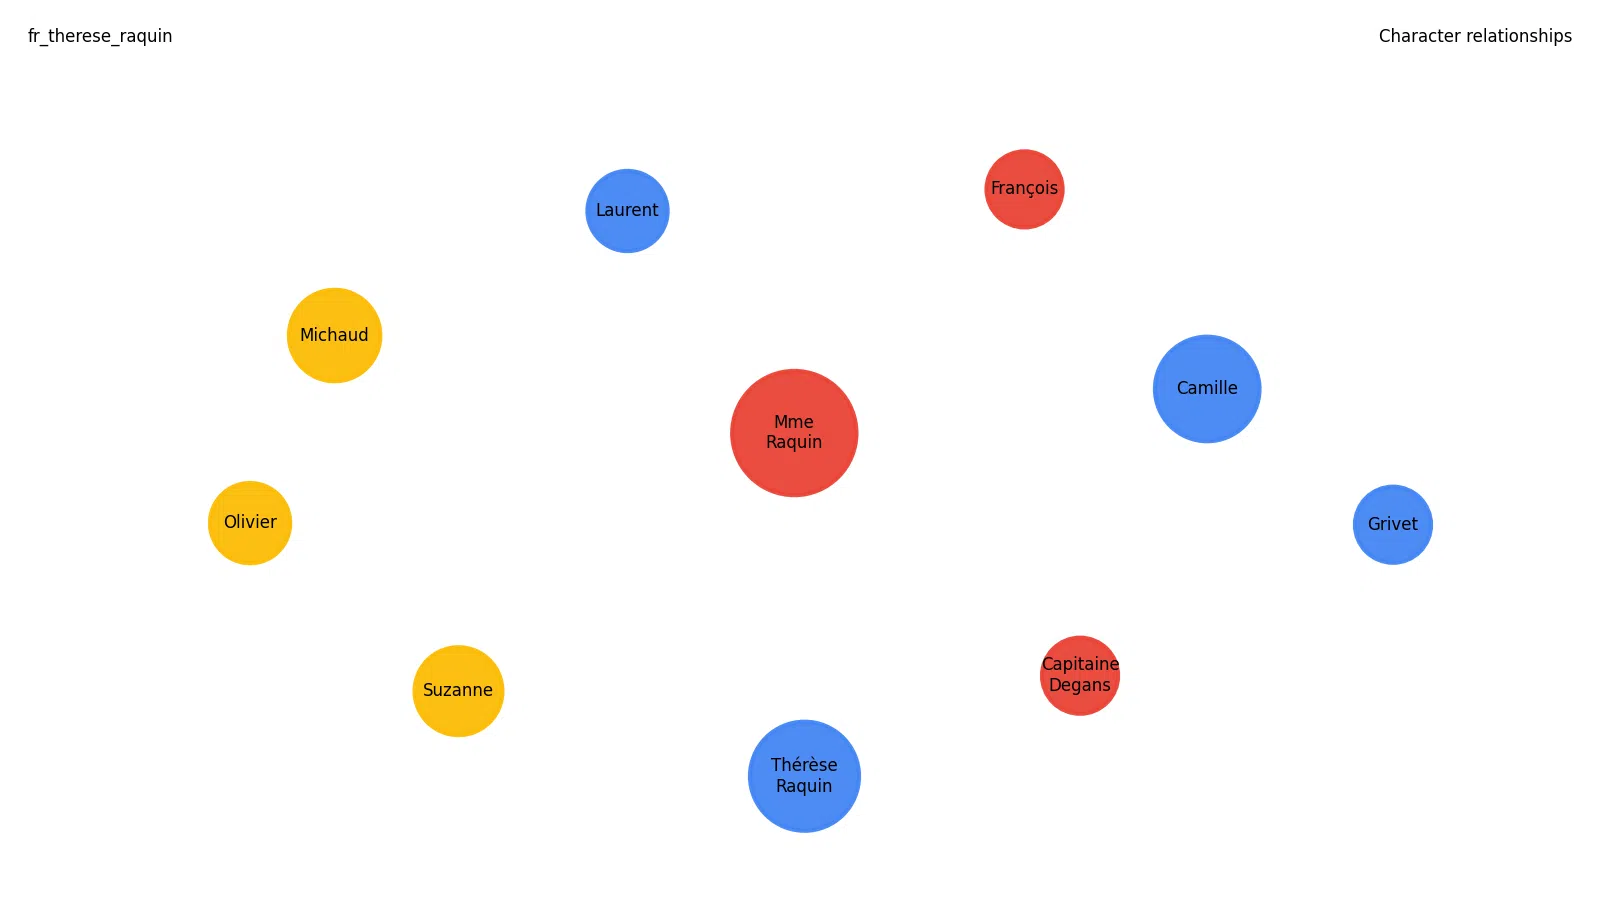

In [18]:
display_text_analysis(source, analysis)

---

## ✅ Challenge completed


In [ ]:
analyze_text(Text.en_les_misérables)

In [ ]:
analyze_text(Text.en_three_musketeers)

In [ ]:
analyze_text(Text.fr_comte_de_monte_cristo_1)

In [ ]:
analyze_text(Collection.fr_comte_de_monte_cristo)

In [ ]:
analyze_text(Collection.fr_comte_de_monte_cristo, model=Model.GEMINI_2_5_PRO)

---

## 💡 Analyze your content


In [ ]:
from pathlib import Path

FILE_PREFIX = "file://"
LOCAL_FOLDER = "./"


def project_gutenberg_url(id: int) -> str:
    return f"https://gutenberg.org/cache/epub/{id}/pg{id}.txt"


def local_file(filename: str) -> str:
    return f"{FILE_PREFIX}{LOCAL_FOLDER}{filename}"


class MyDocs(Source):
    # Classics
    # You can find public domain books on Project Gutenberg: https://gutenberg.org/ebooks
    fr_zola_thérèse_raquin = project_gutenberg_url(7461)
    fr_zola_germinal = project_gutenberg_url(5711)
    de_Goethe_Faust_Der_Tragödie_erster_Teil = project_gutenberg_url(2229)
    de_Goethe_Die_Leiden_des_jungen_Werther = project_gutenberg_url(2407)
    de_Grimmelshausen_Der_abenteuerliche_Simplicissimus = project_gutenberg_url(55171)
    de_Fontane_Effi_Briest = project_gutenberg_url(5323)

    # Local text files
    local_txt_my_file = local_file("my_file.txt")

    # Add your own docs (adapt `yield_contents` for non-HTTP URIs)
    pass

    def yield_contents(self) -> Iterator[Part]:
        file_uri = self.value
        if file_uri.startswith(FILE_PREFIX):
            file = Path(file_uri.removeprefix(FILE_PREFIX))
            assert file.exists()
            text = file.read_text(encoding="utf-8")
            yield Part.from_text(text=text)
        else:
            yield Part.from_uri(file_uri=file_uri, mime_type="text/plain")

In [ ]:
analyze_text(MyDocs.fr_zola_germinal)

In [ ]:
# analyze_text(MyDocs.local_txt_my_file)

---

## 🏁 Conclusion


We managed to extract and build knowledge graphs from documents with the following steps:

- Prototyping with open prompts to develop intuition on Gemini's natural strengths
- Crafting more and more specific prompts to reach a tabular extraction strategy
- Generating structured outputs to converge towards production-ready code
- Adding data visualization for easier response understanding and smoother iterations
- Conducting more tests and iterations

Those principles should apply to many other data extraction domains and let you solve your own complex problems. Have fun and get solving!


---

## ➕ More!

- Explore typical use cases in the [Vertex AI Prompt Gallery](https://console.cloud.google.com/vertex-ai/studio/prompt-gallery)
- Stay updated with the [Vertex AI Release Notes](https://cloud.google.com/vertex-ai/generative-ai/docs/release-notes)
